# Typology Features Impact on LightGBM — Huber Conservative

## Overview

This notebook evaluates whether adding demand typology labels — derived in `Product_Clustering_Method.ipynb` — as input features improves the anomaly detection performance of the Huber Conservative LightGBM configuration selected as the production model.

The baseline model (without typology) replicates the Huber Conservative configuration from `LightGBM_Final_Methodology_Test.ipynb`. The augmented model adds four categorical features encoding each product's demand profile: monthly seasonality type, holiday concentration flag, weekly pattern, and intraday pattern.

Both models are evaluated at z > 4.0 across the same set of diagnostics: alert volume, statistical signal strength, anomaly depth, and recall on 65 labelled injected anomalies.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import gc
import warnings
warnings.filterwarnings('ignore')

DATA_PATH     = r'data_v1.csv'
AUG_FULL_PATH = r'df_aug_final.csv'
AUG_ZERO_PATH = r'df_aug_final_check_rows.csv'

RANDOM_STATE  = 42
Z_THRESHOLD   = 4.0

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

### Data Loading and Typology Construction

Loads the main dataset, removes cold-start products, and reconstructs the four-label demand typology from `Product_Clustering_Method.ipynb` using the same feature computation and classification rules.

In [2]:
df = pd.read_csv(DATA_PATH)
df['date']    = pd.to_datetime(df['date'])
df['product'] = df['product'].astype(str)

first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
cold      = first_pos[first_pos >= '2025-08-01'].index
df        = df[~df['product'].isin(cold)].copy()
df        = df[df['date'] <= '2025-08-31'].copy()

df['hour']       = df['date'].dt.hour
df['dayofweek']  = df['date'].dt.dayofweek
df['month']      = df['date'].dt.month

df_aug_zero = pd.read_csv(AUG_ZERO_PATH)
df_aug_zero['date'] = pd.to_datetime(df_aug_zero['date'])

df_active = df[df['sales'] > 0].copy()

def share_pivot(d, col):
    p = d.groupby(['product', col])['sales'].count().unstack(fill_value=0)
    return p.div(p.sum(axis=1), axis=0).add_prefix(f'{col}_share_')

fa = (
    df_active.groupby('product')['sales'].agg(
        mean_sales_active='mean',
        cv_active=lambda x: x.std() / (x.mean() + 1e-6),
        n_active_hours='count',
        p90_active=lambda x: np.percentile(x, 90),
    )
    .join(share_pivot(df_active, 'dayofweek'))
    .join(share_pivot(df_active, 'month'))
    .join(share_pivot(df_active, 'hour'))
    .fillna(0)
    .reset_index()
)

def safe_sum(df, cols):
    existing = [c for c in cols if c in df.columns]
    return df[existing].sum(axis=1) if existing else pd.Series(0, index=df.index)

fa['share_winter'] = safe_sum(fa, ['month_share_1','month_share_2','month_share_12'])
fa['share_spring'] = safe_sum(fa, ['month_share_3','month_share_4','month_share_5'])
fa['share_summer'] = safe_sum(fa, ['month_share_6','month_share_7','month_share_8'])
fa['share_autumn'] = safe_sum(fa, ['month_share_9','month_share_10','month_share_11'])
fa['share_fri_sat']  = safe_sum(fa, ['dow_share_4','dow_share_5'])
fa['share_weekend']  = safe_sum(fa, ['dow_share_5','dow_share_6'])
fa['share_weekdays'] = safe_sum(fa, ['dow_share_0','dow_share_1','dow_share_2','dow_share_3','dow_share_4'])

hour_cols_fa = [c for c in fa.columns if c.startswith('hour_share_')]
fa['share_morning']   = fa[[c for c in hour_cols_fa if int(c.split('_')[-1]) in range(6,12)]].sum(axis=1)
fa['share_afternoon'] = fa[[c for c in hour_cols_fa if int(c.split('_')[-1]) in range(12,17)]].sum(axis=1)
fa['share_evening']   = fa[[c for c in hour_cols_fa if int(c.split('_')[-1]) in range(17,23)]].sum(axis=1)
fa['share_night']     = fa[[c for c in hour_cols_fa if int(c.split('_')[-1]) in list(range(0,6))+[23]]].sum(axis=1)

fa['share_holiday'] = safe_sum(fa, ['month_share_2','month_share_3','month_share_5','month_share_12'])
def seasonal_type(row):
    s = {'winter': row['share_winter'], 'spring': row['share_spring'],
         'summer': row['share_summer'], 'autumn': row['share_autumn']}
    best = max(s, key=s.get)
    return best if s[best] >= 0.45 else 'no_seasonality'

def weekly_type(row):
    if row['share_fri_sat'] >= 0.35:   return 'fri_sat_peak'
    elif row['share_weekend'] >= 0.35: return 'weekend_peak'
    elif row['share_weekdays'] >= 0.75: return 'weekday_focused'
    else: return 'uniform_weekly'

def hourly_type(row):
    s = {'morning': row['share_morning'], 'afternoon': row['share_afternoon'],
         'evening': row['share_evening'], 'night': row['share_night']}
    best = max(s, key=s.get)
    return best if s[best] >= 0.40 else 'uniform_hourly'

fa['monthly_type']    = fa.apply(seasonal_type, axis=1)
fa['weekly_type']     = fa.apply(weekly_type, axis=1)
fa['hourly_type']     = fa.apply(hourly_type, axis=1)

summer_share = safe_sum(fa, ['month_share_6','month_share_7',
                              'month_share_8','month_share_9','month_share_10'])
fa['is_holiday_driven'] = (
    (fa['share_holiday'] > 0.55) &
    (summer_share < 0.12)
).astype(int)

print(f"Holiday-driven products: {fa['is_holiday_driven'].sum()}")

typology = fa[['product','monthly_type','weekly_type','hourly_type','is_holiday_driven']].copy()

for col in ['monthly_type','weekly_type','hourly_type']:
    typology[col] = typology[col].astype('category')

print(f"Typology built for {len(typology):,} products")
print(typology[['monthly_type','weekly_type','hourly_type','is_holiday_driven']].describe())

Holiday-driven products: 810
Typology built for 7,775 products
       is_holiday_driven
count        7775.000000
mean            0.104180
std             0.305514
min             0.000000
25%             0.000000
50%             0.000000
75%             0.000000
max             1.000000


### Feature Engineering

Constructs the full feature set used in `LightGBM_Final_Methodology_Test.ipynb`: 13 historical product profile statistics, calendar features, lag features, and rolling statistics. The augmented version additionally merges the four typology labels as categorical input features.

In [3]:
df_til_sep = df[df['date'].dt.month < 8].copy()

products = df_til_sep[['product','category']].drop_duplicates()
first_sales = df_til_sep[df_til_sep['sales'] > 0].groupby('product')['date'].min().reset_index()
first_sales.columns = ['product','first_sale_date']
products = products.merge(first_sales, on='product', how='left')

df_feat = df_til_sep.merge(first_sales, on='product', how='left')
df_feat = df_feat[df_feat['date'] >= df_feat['first_sale_date']]

all_features = df_feat.groupby('product').agg(
    hist_mean=('sales','mean'), hist_std=('sales','std'),
    hist_cv=('sales', lambda x: x.std()/(x.mean()+1e-6)),
    hist_zero=('sales', lambda x: (x==0).mean()),
    hist_adi=('sales', lambda x: (x==0).sum()/max((x>0).sum(),1)),
    hist_max=('sales','max'),
    hist_p99=('sales', lambda x: np.percentile(x,99)),
    hist_peak=('sales', lambda x: x.max()/(x.mean()+1e-6)),
    hist_outlier=('sales', lambda x: (x>np.percentile(x,99)).mean()),
    hist_pos_rate=('sales', lambda x: (x>0).mean()),
    accel=('sales', lambda x: x.iloc[-72:].mean()/(x.iloc[:72].mean()+1e-6) if len(x)>=144 else 1.0),
    recent_vs_avg=('sales', lambda x: x.iloc[-72:].mean()/(x.mean()+1e-6)),
    vol_3d=('sales', lambda x: x.iloc[-72:].std()/(x.iloc[-72:].mean()+1e-6) if len(x)>=72 else 0.0)
).reset_index()

products = products.merge(all_features, on='product', how='left')
profile_cols = [c for c in all_features.columns if c != 'product']
for col in profile_cols:
    med = products.groupby('category')[col].median()
    products.loc[products[col].isna(), col] = products.loc[products[col].isna(),'category'].map(med)
products[profile_cols] = products[profile_cols].replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')

del df_feat, all_features
gc.collect()

def build_features(df_in):
    out = df_in.merge(products, on=['product','category'], how='left')
    out = out.sort_values(['product','date']).reset_index(drop=True)
    out['hour']          = out['date'].dt.hour
    out['dayofweek']     = out['date'].dt.dayofweek
    out['is_weekend']    = (out['dayofweek'] >= 5).astype(int)
    out['week']          = out['date'].dt.isocalendar().week
    out['stocks_lag_1h'] = out.groupby('product')['stocks'].shift(1).fillna(0)
    for lag in [1, 24, 168]:
        out[f'sales_lag_{lag}h'] = out.groupby('product')['sales'].shift(lag)
    for w in [6, 24, 168]:
        mp = max(1, w//2)
        out[f'rolling_mean_{w}h'] = out.groupby('product')['sales'].transform(
            lambda x: x.rolling(w, min_periods=mp).mean())
        out[f'rolling_std_{w}h']  = out.groupby('product')['sales'].transform(
            lambda x: x.rolling(w, min_periods=mp).std())
    out['z_score_24h']       = (out['sales'] - out['rolling_mean_24h']) / (out['rolling_std_24h'] + 1e-6)
    out['pct_change_1h']     = out.groupby('product')['sales'].pct_change(1)
    out['pct_change_24h']    = out.groupby('product')['sales'].pct_change(24)
    out['sales_vs_mean_24h'] = out['sales'] / (out['rolling_mean_24h'] + 1e-6)
    num_cols = out.select_dtypes(include=['float32','float64','int32','int64']).columns
    out[num_cols] = out[num_cols].replace([np.inf,-np.inf],np.nan).fillna(0)
    return out

df_train_raw = build_features(df[df['date'].dt.month < 8].copy())

df_aug_raw = df[df['date'] >= '2025-08-01'].copy()
df_aug_orig = build_features(df_aug_raw)
df_aug_orig = df_aug_orig.merge(
    df_aug_zero[['product','date']].assign(is_injected=1),
    on=['product','date'], how='left'
)
df_aug_orig.loc[df_aug_orig['is_injected'] == 1, 'sales'] = 0
df_aug_orig = df_aug_orig.drop(columns='is_injected')

exclude = ['product','date','category','first_sale_date','sales','price', 'month']
base_features = [c for c in df_train_raw.columns if c not in exclude]

print(f"Train: {len(df_train_raw):,} | Test: {len(df_aug_orig):,} | Base features: {len(base_features)}")
print(f"Profile cols in test: {all(c in df_aug_orig.columns for c in profile_cols)}")

Train: 36,387,600 | Test: 5,081,342 | Base features: 32
Profile cols in test: True


### Model Training and Anomaly Detection

Two Huber Conservative models are trained with identical hyperparameters. The baseline uses the standard feature set. The augmented model additionally receives the four typology labels as categorical features. Both are evaluated at z > 4.0 with the mandatory domain filter: positive stock in the current and preceding hour, business hours 07:00–22:00.

In [5]:
PARAMS = {
    'objective': 'huber',
    'alpha': 0.9,
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 1200,
    'num_leaves': 31,
    'max_depth': 7,
    'min_child_samples': 200,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'subsample': 0.7,
    'colsample_bytree': 0.6,
    'max_bin': 255,
    'verbose': -1,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

def train_and_detect(label, train_df, test_df, features):
    val_mask = (train_df['date'] >= '2025-07-25') & (train_df['date'] < '2025-08-01')
    X_tr, y_tr = train_df.loc[~val_mask, features], train_df.loc[~val_mask, 'sales']
    X_val, y_val = train_df.loc[val_mask, features], train_df.loc[val_mask, 'sales']
    sw_tr  = np.where(y_tr > 0, 3, 1)
    sw_val = np.where(y_val > 0, 3, 1)

    model = lgb.LGBMRegressor(**PARAMS)
    model.fit(X_tr, y_tr, sample_weight=sw_tr,
              eval_set=[(X_val, y_val)], eval_sample_weight=[sw_val],
              callbacks=[lgb.early_stopping(10, verbose=False), lgb.log_evaluation(period=200)])

    res = test_df.copy()
    res['predicted'] = model.predict(test_df[features])
    res['residual']  = res['predicted'] - res['sales']
    res['res_z']     = (res['residual'] - res['residual'].mean()) / res['residual'].std()

    res['passes_filter'] = (
        (res['stocks_lag_1h'] > 0) &
        (res['stocks'] > 0) &
        (res['hour'] >= 7) &
        (res['hour'] <= 22) &
        (res['sales'] < res['predicted'])
    )
    anomalies = res[res['passes_filter'] & (res['res_z'] > Z_THRESHOLD)]

    matches = len(anomalies.merge(df_aug_zero[['product','date']], on=['product','date'], how='inner'))

    pre = df[df['date'] < '2025-08-01'][['product','date','sales']].copy()
    hist = pre.groupby('product')['sales'].agg(h_mean='mean', h_std='std').reset_index()
    hist['h_std'] = hist['h_std'].fillna(0)
    anom_eval = anomalies.merge(hist, on='product', how='left')
    anom_eval['z_hist'] = (anom_eval['sales'] - anom_eval['h_mean']) / (anom_eval['h_std'] + 1e-6)
    for col in ['h_mean', 'h_std']:
        anom_eval[col] = anom_eval[col].replace(0, np.nan).fillna(1)
    anom_eval['dev_pct'] = (anom_eval['sales'] - anom_eval['h_mean']) / anom_eval['h_mean'] * 100
    drop_mask = anom_eval['sales'] < anom_eval['h_mean']

    n = len(anomalies)
    print(f"  {label}")
    print(f"  Anomalies found:          {n:,}  ({n/31:.1f}/day)")
    print(f"  Unique products:          {anomalies['product'].nunique()}")
    print(f"  Recall on 65 injected:    {matches} / 65  ({matches/65*100:.1f}%)")
    print(f"  Mean |z_hist|:            {anom_eval['z_hist'].abs().mean():.3f}")
    print(f"  % |z_hist| > 2:           {(anom_eval['z_hist'].abs() > 2).mean()*100:.1f}%")
    print(f"  Mean deviation from norm: {anom_eval.loc[drop_mask, 'dev_pct'].mean():.1f}%")
    print(f"  % drops > 50% below norm: {(anom_eval['dev_pct'] < -50).mean()*100:.1f}%")

    return anomalies, anom_eval, model

# wo segmentation
X_test_base = df_aug_orig.copy()
anomalies_base, eval_base, model_base = train_and_detect(
    "Huber Conservative — baseline (no typology)",
    df_train_raw, X_test_base, base_features
)

df_train_aug = df_train_raw.merge(typology, on='product', how='left')
df_test_aug  = df_aug_orig.merge(typology, on='product', how='left')

for col in ['monthly_type','weekly_type','hourly_type']:
    df_train_aug[col] = df_train_aug[col].astype('category')
    df_test_aug[col]  = df_test_aug[col].astype('category')

typology_features = base_features + ['monthly_type','weekly_type','hourly_type','is_holiday_driven']
anomalies_aug, eval_aug, model_aug = train_and_detect(
    "Huber Conservative — augmented (with typology)",
    df_train_aug, df_test_aug, typology_features
)

[200]	valid_0's l1: 0.0337285
[400]	valid_0's l1: 0.0195047
[600]	valid_0's l1: 0.0142261
[800]	valid_0's l1: 0.0115167
[1000]	valid_0's l1: 0.00992787
[1200]	valid_0's l1: 0.00886861
  Huber Conservative — baseline (no typology)
  Anomalies found:          210  (6.8/day)
  Unique products:          55
  Recall on 65 injected:    60 / 65  (92.3%)
  Mean |z_hist|:            2.778
  % |z_hist| > 2:           35.2%
  Mean deviation from norm: -117.7%
  % drops > 50% below norm: 42.9%
[200]	valid_0's l1: 0.0329844
[400]	valid_0's l1: 0.0191811
[600]	valid_0's l1: 0.0139746
[800]	valid_0's l1: 0.011232
[1000]	valid_0's l1: 0.00955639
[1200]	valid_0's l1: 0.00846613
  Huber Conservative — augmented (with typology)
  Anomalies found:          230  (7.4/day)
  Unique products:          76
  Recall on 65 injected:    60 / 65  (92.3%)
  Mean |z_hist|:            3.479
  % |z_hist| > 2:           30.4%
  Mean deviation from norm: -113.2%
  % drops > 50% below norm: 50.4%


### Comparative Results and Visualizations

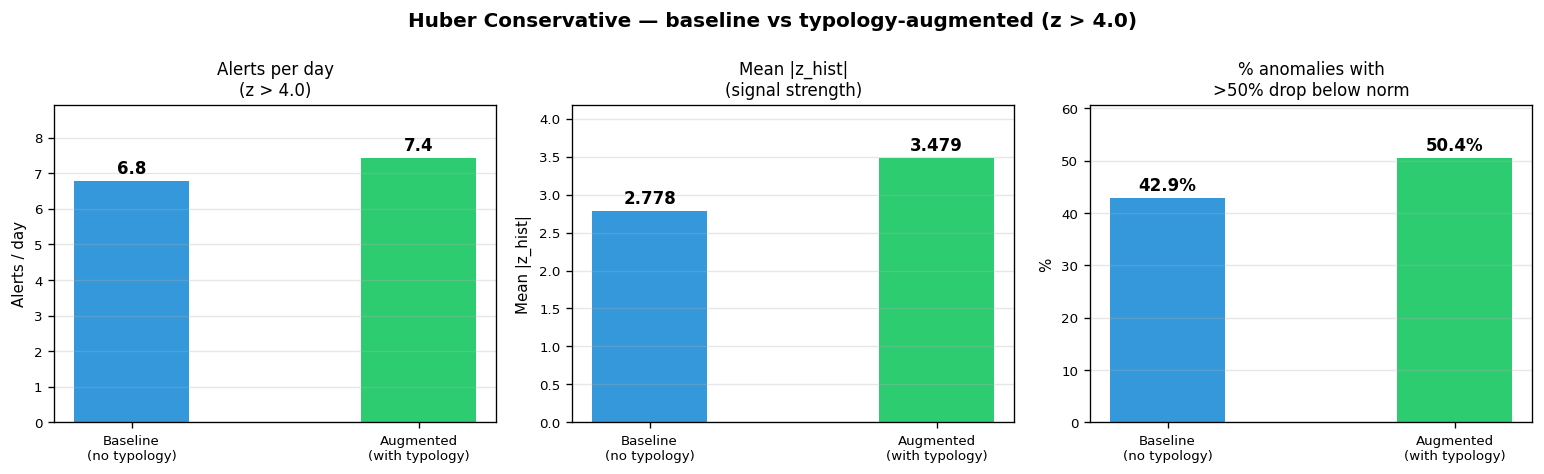

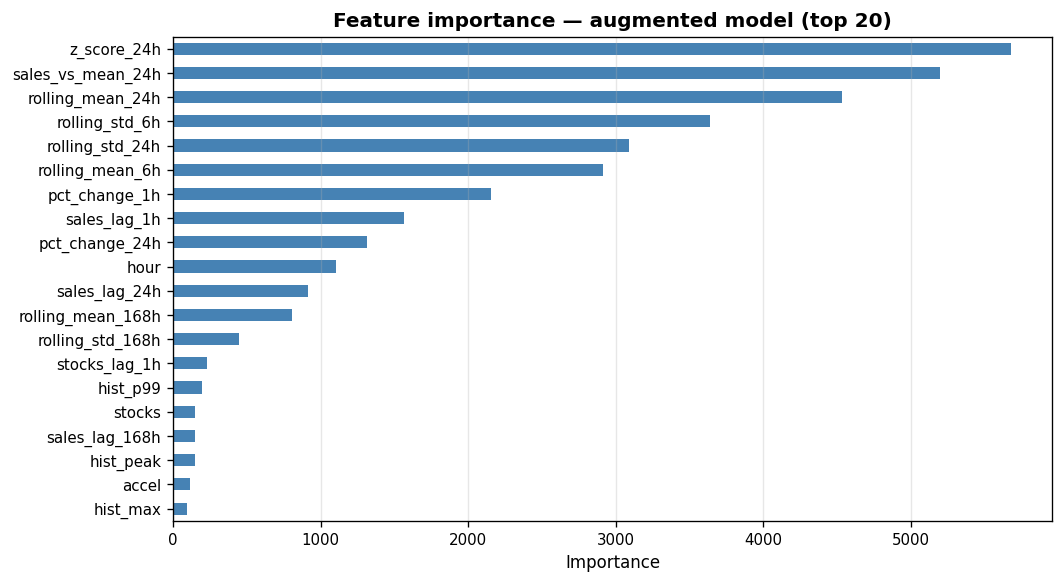

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

labels = ['Baseline\n(no typology)', 'Augmented\n(with typology)']
colors = ['#3498db', '#2ecc71']

alerts = [len(anomalies_base)/31, len(anomalies_aug)/31]
axes[0].bar(labels, alerts, color=colors, width=0.4)
axes[0].set_title('Alerts per day\n(z > 4.0)', fontsize=10)
axes[0].set_ylabel('Alerts / day', fontsize=9)
max_val1 = max(alerts)
for bar, val in zip(axes[0].patches, alerts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val1*0.03, 
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylim(0, max_val1 * 1.2)  # Add 20% headroom
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(labelsize=8)

z_vals = [eval_base['z_hist'].abs().mean(), eval_aug['z_hist'].abs().mean()]
axes[1].bar(labels, z_vals, color=colors, width=0.4)
axes[1].set_title('Mean |z_hist|\n(signal strength)', fontsize=10)
axes[1].set_ylabel('Mean |z_hist|', fontsize=9)
max_val2 = max(z_vals)
for bar, val in zip(axes[1].patches, z_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val2*0.03, 
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylim(0, max_val2 * 1.2)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(labelsize=8)

# Plot 3: Deep anomalies
deep = [(eval_base['dev_pct'] < -50).mean()*100, (eval_aug['dev_pct'] < -50).mean()*100]
axes[2].bar(labels, deep, color=colors, width=0.4)
axes[2].set_title('% anomalies with\n>50% drop below norm', fontsize=10)
axes[2].set_ylabel('%', fontsize=9)
max_val3 = max(deep)
for bar, val in zip(axes[2].patches, deep):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val3*0.03, 
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[2].set_ylim(0, max_val3 * 1.2)
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(labelsize=8)

plt.suptitle('Huber Conservative — baseline vs typology-augmented (z > 4.0)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

imp = pd.Series(model_aug.feature_importances_, 
                index=typology_features).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 5))
imp[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importance — augmented model (top 20)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', fontsize=10)
ax.tick_params(labelsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

The experiment provides a nuanced picture: adding demand typology labels 
modestly changes the behaviour of the Huber Conservative LightGBM model 
but does not produce a clear net improvement that would justify the 
additional preprocessing complexity.

**Recall** is identical across both configurations at 60 / 65 (92.3%), 
confirming that the typology labels neither help nor hinder the detection 
of controlled anomalies.

**Alert volume** increased slightly from 6.8 to 7.4 alerts per day 
(210 vs 230 flagged events in August), a 9.5% rise. The augmented model 
covers more unique products (76 vs 55), indicating broader but less 
focused detection.

**Signal strength** presents a mixed result. The mean |z_hist| rose from 
2.778 (baseline) to 3.479 (augmented), suggesting that the augmented 
model's flagged events are, on average, more extreme relative to each 
product's historical baseline. However, the share of anomalies with 
|z_hist| > 2 decreased from 35.2% to 30.4%, indicating that the 
augmented model also introduces a larger share of statistically marginal 
flags near the detection boundary. The higher mean is therefore driven 
by a few highly extreme events rather than uniformly stronger signals 
across the board.

**Anomaly depth** shifted in favour of the augmented model: the share of 
drops exceeding 50% below historical norm rose from 42.9% to 50.4%. 
Mean deviation from norm remained comparable (−117.7% vs −113.2%).

**Feature importance** provides the key explanation for the limited 
impact. None of the four typology labels appear in the top 20 features 
of the augmented model. The dominant features remain z_score_24h, 
sales_vs_mean_24h, rolling_mean_24h, rolling_std_6h, and 
rolling_std_24h — all computed at the individual product level over 
recent history. These rolling and lag features already capture local 
demand context implicitly: a product with structurally low weekend sales 
will have a correspondingly low rolling mean on weekends, so the model 
does not need an external label to infer that pattern. The typology 
labels would add value only if the model could not derive seasonal 
context from the time-series features alone, which is not the case 
given a 168-hour rolling window.

**Conclusion.** While the augmented model shows marginally deeper 
anomaly detection and higher mean signal strength, these gains come at 
the cost of a 9.5% increase in daily alert volume and a broader, less 
focused detection scope. The typology labels do not enter the top 20 
features and produce no improvement in recall. The rule-based demand 
typology remains a valuable analytical instrument for understanding 
catalogue structure and communicating seasonality patterns to business 
stakeholders. However, as a machine learning feature it is effectively 
redundant given the rolling feature set already available to the model. 
The baseline Huber Conservative configuration without typology labels 
is confirmed as the recommended production setup on the grounds of 
operational parsimony: equivalent recall, lower alert volume, and no 
additional preprocessing requirements.